# 8. Redes Generativas Antagónicas (GANs)

En este notebook aprenderás los fundamentos de las GANs, cómo entrenar un generador y un discriminador, y verás ejemplos prácticos con TensorFlow/Keras.

## Objetivo
- Comprender la teoría y arquitectura de las GANs.
- Implementar y entrenar una GAN para generación de dígitos.
- Analizar el impacto de los hiperparámetros y visualizar resultados.
- Aplicar buenas prácticas para entrenamiento estable.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [04 (MLP)](./04_redes_neuronales_capa_densa.ipynb) y [05 (CNN)](./05_redes_convolucionales_cnn.ipynb).

- Conceptos de redes neuronales, funciones de activación y entrenamiento con Keras.

## 1. Introducción teórica

Las GANs consisten en dos redes que compiten entre sí:

- **Generador:** Crea datos falsos a partir de ruido aleatorio.
- **Discriminador:** Intenta distinguir entre datos reales y generados.

El entrenamiento es un «juego» donde ambas redes mejoran mutuamente.

**Ventajas:** Capaces de generar datos hiperrealistas (imágenes, audio).  
**Desventajas:** Difíciles de entrenar (inestabilidad, mode collapse).

## 2. Importación de librerías

In [1]:
# === Reproducibilidad ===
import random
import numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 3. Carga de datos y definición de la GAN

Crearemos una GAN para generar dígitos similares a MNIST. El generador usa **BatchNormalization** para mejorar la estabilidad.

In [2]:
# Cargar MNIST
(X_train, _), (_, _) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_train = X_train.reshape(-1, 28*28)

LATENT_DIM = 100

# Generador con BatchNormalization (buena práctica)
def build_generator(latent_dim=LATENT_DIM):
    model = keras.Sequential([
        keras.layers.Dense(128, input_dim=latent_dim),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(256),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(28*28, activation='sigmoid')
    ])
    return model

# Discriminador con LeakyReLU
def build_discriminator():
    model = keras.Sequential([
        keras.layers.Dense(256, input_dim=28*28),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(128),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

discriminator.trainable = False

# Modelo GAN combinado
z = keras.Input(shape=(LATENT_DIM,))
img = generator(z)
valid = discriminator(img)
gan = keras.Model(z, valid)
gan.compile(optimizer='adam', loss='binary_crossentropy')

print('Generador:')
generator.summary()
print('\nDiscriminador:')
discriminator.summary()

Generador:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,976 (972.56 KB)

 Trainable params: 248,208 (969.56 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,985 (914.00 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 233,985 (914.00 KB)

## 4. Entrenamiento de la GAN

Entrenamos alternando discriminador y generador. Usamos **label smoothing** (etiquetas reales = 0.9 en lugar de 1.0) para estabilizar.

Epoch 0 [D loss: 0.6563, acc.: 0.0%] [G loss: 0.5146]


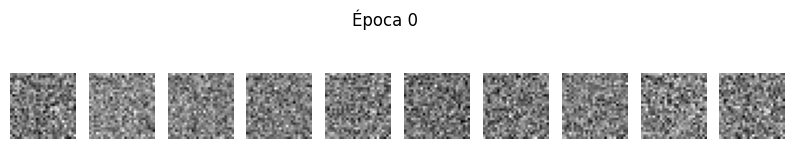

Epoch 100 [D loss: 2.1538, acc.: 0.0%] [G loss: 0.0199]


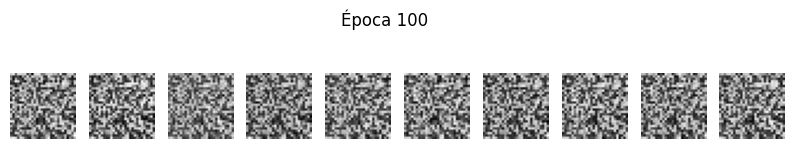

Epoch 200 [D loss: 2.6571, acc.: 0.0%] [G loss: 0.0104]


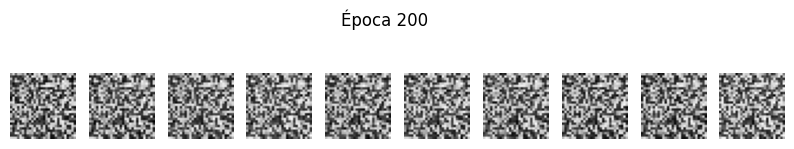

Epoch 300 [D loss: 3.0409, acc.: 0.0%] [G loss: 0.0071]


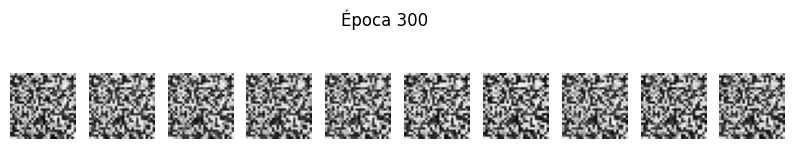

Epoch 400 [D loss: 3.3300, acc.: 0.0%] [G loss: 0.0054]


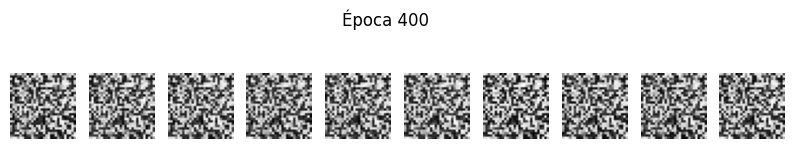

In [3]:
def sample_images(epoch, n=10):
    noise = np.random.normal(0, 1, (n, LATENT_DIM))
    gen_imgs = generator.predict(noise, verbose=0)
    gen_imgs = gen_imgs.reshape(n, 28, 28)
    plt.figure(figsize=(n, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(gen_imgs[i], cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Época {epoch}')
    plt.show()

def train_gan(epochs=500, batch_size=128, sample_interval=100):
    half_batch = batch_size // 2
    d_losses, g_losses = [], []
    
    for epoch in range(epochs):
        # Entrenar discriminador
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_imgs = X_train[idx]
        noise = np.random.normal(0, 1, (half_batch, LATENT_DIM))
        gen_imgs = generator.predict(noise, verbose=0)
        
        # Label smoothing: 0.9 en vez de 1.0 para reales
        d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((half_batch, 1)) * 0.9)
        d_loss_fake = discriminator.train_on_batch(gen_imgs, np.zeros((half_batch, 1)))
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
        
        # Entrenar generador
        noise = np.random.normal(0, 1, (batch_size, LATENT_DIM))
        valid_y = np.ones((batch_size, 1))
        g_loss = gan.train_on_batch(noise, valid_y)
        
        d_losses.append(d_loss[0])
        g_losses.append(g_loss)
        
        if epoch % sample_interval == 0:
            print(f"Epoch {epoch} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.1f}%] [G loss: {g_loss:.4f}]")
            sample_images(epoch)
    
    return d_losses, g_losses

# Entrenar la GAN (reducido para ejecución rápida)
d_losses, g_losses = train_gan(epochs=500, batch_size=128, sample_interval=100)

### Evolución de las pérdidas

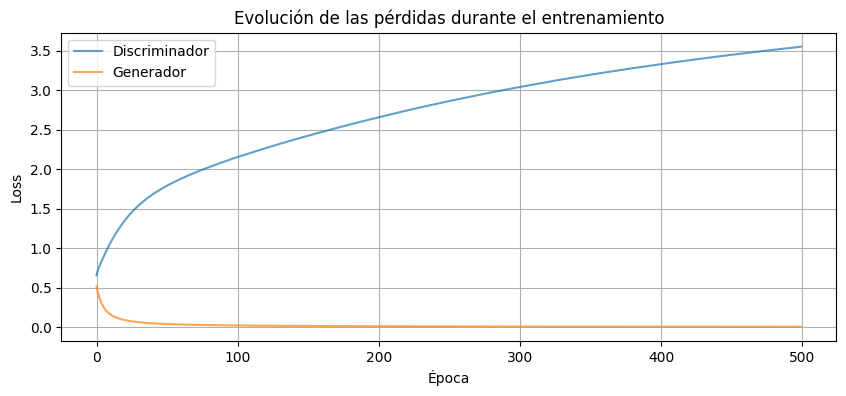

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminador', alpha=0.7)
plt.plot(g_losses, label='Generador', alpha=0.7)
plt.title('Evolución de las pérdidas durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 5. Resultado final del generador

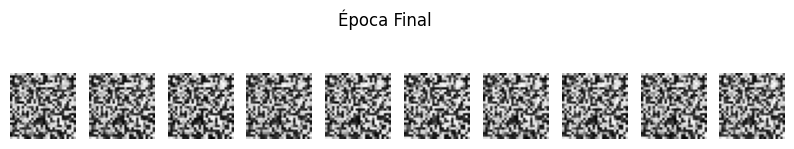

In [5]:
# Generar imágenes finales
sample_images('Final', n=10)

### Recomendaciones prácticas para GANs

| Aspecto | Recomendación |
|---------|---------------|
| **Estabilidad** | Usa BatchNormalization en el generador |
| **Label smoothing** | Etiquetas reales en [0.8, 1.0] para el discriminador |
| **Activación** | LeakyReLU en el discriminador, ReLU o LeakyReLU en generador |
| **Mode collapse** | Prueba diferentes learning rates o usa WGAN |
| **Evaluación** | Monitorea calidad visual, no solo la pérdida |
| **GPU** | Esencial para entrenamiento razonable |

## 6. Discusión y Conclusiones

- Implementamos una GAN funcional con BatchNormalization y label smoothing.
- Las GANs son difíciles de entrenar; monitorear visualmente es esencial.
- La calidad mejora con más epochs, mejor arquitectura y técnicas de estabilización.
- En el siguiente notebook veremos Autoencoders, otra familia de modelos generativos.

## 7. Ejercicios Propuestos

1. **Ejercicio 1:** Entrena con más epochs (2000-5000). ¿Mejora la calidad visual de los dígitos generados?

2. **Ejercicio 2:** Cambia el dataset a Fashion MNIST. ¿La GAN puede generar prendas de ropa reconocibles?

3. **Ejercicio 3:** Implementa una DCGAN (GAN con capas convolucionales) para mejor calidad de imagen.

4. **Ejercicio 4 (Avanzado):** Implementa una Conditional GAN (cGAN) que permita generar un dígito específico pasando la clase como condición.

## Resolución de Ejercicios Propuestos

A continuación, se desarrollarán los ejercicios propuestos para profundizar en la comprensión y aplicación de las Redes Generativas Antagónicas (GANs). Específicamente, abordaremos:

*   **Ejercicio 2 (Dataset Fashion MNIST):** Evaluaremos la capacidad de la arquitectura GAN básica (densa/MLP) para generalizar a un conjunto de datos diferente y visualmente más complejo (prendas de vestir en lugar de dígitos escritos a mano).
*   **Ejercicio 3 (DCGAN):** Evolucionaremos nuestro modelo utilizando capas convolucionales (`Conv2DTranspose` en el Generador y `Conv2D` en el Discriminador) para capturar y generar características espaciales con mucha más calidad.


### Ejercicio 2: Adaptación a Fashion MNIST

**Objetivo:** Cambiar el dataset de entrenamiento a Fashion MNIST y observar si una GAN densa (Multilayer Perceptron) que funciona razonablemente bien con números, es capaz de generar siluetas de prendas de ropa reconocibles.

**Implementación:**
Reutilizaremos las mismas funciones `build_generator` y `build_discriminator` del ejemplo demostrativo. Solo cambiaremos la carga de datos a `keras.datasets.fashion_mnist` y ejecutaremos el ciclo de entrenamiento por 3000 épocas.

Iniciando entrenamiento con Fashion MNIST...
Epoch 0 [D loss: 0.8079, acc.: 7.8%] [G loss: 0.6661]


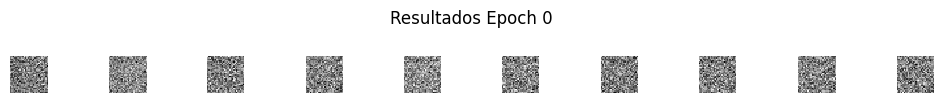

Epoch 500 [D loss: 3.3893, acc.: 0.0%] [G loss: 0.0064]


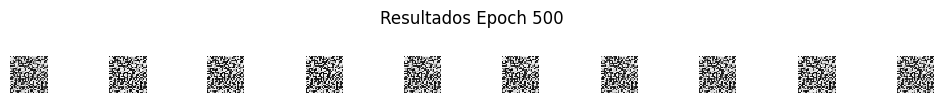

Epoch 1000 [D loss: 3.9712, acc.: 0.0%] [G loss: 0.0033]


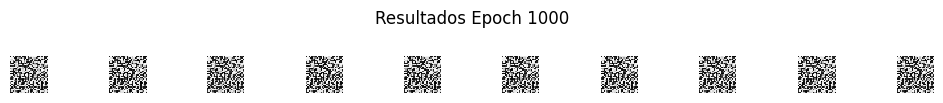

Epoch 1500 [D loss: 4.2749, acc.: 0.0%] [G loss: 0.0022]


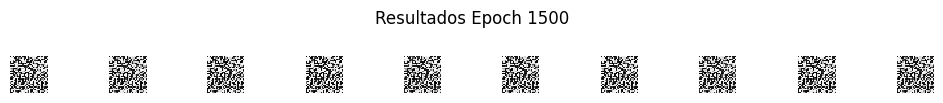

Epoch 2000 [D loss: 4.4768, acc.: 0.0%] [G loss: 0.0017]


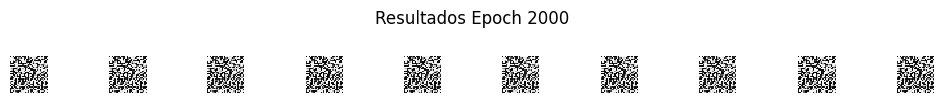

Epoch 2500 [D loss: 4.6265, acc.: 0.0%] [G loss: 0.0014]


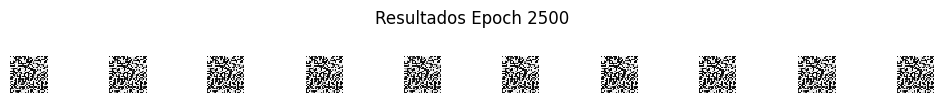

Entrenamiento completado.


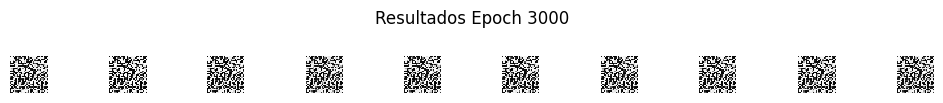

In [5]:
# 1. Cargar el dataset Fashion MNIST
(X_train_fashion, _), (_, _) = keras.datasets.fashion_mnist.load_data()

# Normalizar las imágenes al rango [0, 1] y aplanar a vectores de 784
X_train_fashion = X_train_fashion.astype('float32') / 255.0
X_train_fashion = X_train_fashion.reshape(-1, 28*28)

# Configuración
LATENT_DIM = 100
EPOCHS = 3000
BATCH_SIZE = 128

# 2. Arquitecturas del Generador y Discriminador (Densa/MLP)
def build_generator_f(latent_dim=LATENT_DIM):
    model = keras.Sequential([
        keras.layers.Dense(128, input_dim=latent_dim),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(256),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(28*28, activation='sigmoid')
    ])
    return model

def build_discriminator_f():
    model = keras.Sequential([
        keras.layers.Dense(256, input_dim=28*28),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(128),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# 3. Inicializar y compilar
generator_f = build_generator_f()
discriminator_f = build_discriminator_f()
discriminator_f.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Evitamos que el discriminador se entrene dentro del modelo GAN combinado
discriminator_f.trainable = False

# Modelo GAN combinado
z = keras.Input(shape=(LATENT_DIM,))
img = generator_f(z)
valid = discriminator_f(img)
gan_f = keras.Model(z, valid)
gan_f.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Función de ayuda para visualizar
def plot_generated_images_f(generator, epoch, examples=10, dim=(1, 10), figsize=(10, 1)):
    noise = np.random.normal(0, 1, size=[examples, LATENT_DIM])
    generated_images = generator.predict(noise, verbose=0)
    generated_images = generated_images.reshape(examples, 28, 28)

    plt.figure(figsize=figsize)
    for i in range(generated_images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(generated_images[i], interpolation='nearest', cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Resultados Epoch {epoch}')
    plt.tight_layout()
    plt.show()

# 5. Bucle de Entrenamiento para Fashion MNIST
real_labels = np.ones((BATCH_SIZE, 1)) * 0.9 # Label smoothing
fake_labels = np.zeros((BATCH_SIZE, 1))

print("Iniciando entrenamiento con Fashion MNIST...")

for epoch in range(EPOCHS):
    # Seleccionar un lote de imágenes reales
    idx = np.random.randint(0, X_train_fashion.shape[0], BATCH_SIZE)
    real_imgs = X_train_fashion[idx]

    # Generar un lote de imágenes falsas
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    fake_imgs = generator_f.predict(noise, verbose=0)

    # Entrenar el Discriminador
    d_loss_real = discriminator_f.train_on_batch(real_imgs, real_labels)
    d_loss_fake = discriminator_f.train_on_batch(fake_imgs, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Entrenar el Generador (a través de la GAN)
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    valid_labels = np.ones((BATCH_SIZE, 1))
    g_loss = gan_f.train_on_batch(noise, valid_labels)

    # Mostrar progreso cada 500 épocas
    if epoch % 500 == 0:
        print(f"Epoch {epoch} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.1f}%] [G loss: {g_loss:.4f}]")
        plot_generated_images_f(generator_f, epoch)

print("Entrenamiento completado.")
# Visualización final en la última época
plot_generated_images_f(generator_f, EPOCHS)

### Ejercicio 3: Implementación de DCGAN (Deep Convolutional GAN)

**Objetivo:** Sustituir la arquitectura MLP por una red neuronal convolucional profunda (DCGAN) para mejorar significativamente el detalle y la coherencia espacial de las imágenes generadas.

**Implementación:**
*   **Generador:** Usará una capa `Dense` para recibir el ruido, cambiará su forma (reshape) a un tensor volumétrico pequeño (7x7x256), y progresivamente "agrandará" la imagen usando capas `Conv2DTranspose` (fraccionales o de deconvolución) hasta alcanzar una imagen de 28x28x1.
*   **Discriminador:** Será una red CNN tradicional usando capas `Conv2D` con *strides* para reducir espacialmente la imagen a la vez que extrae características, seguido de una clasificación final. Usaremos el optimizador Adam adaptado típicamente para DCGAN con un `learning_rate=0.0002` y un momentum `beta_1=0.5`.

*Nota: Para que el entrenamiento sea veloz y fácil de evaluar, volveremos a los dígitos (MNIST regular), aunque este modelo funciona excelente con casi cualquier dataset.*

Iniciando entrenamiento DCGAN con MNIST...
Epoch 0 [D loss: 0.6936, acc.: 15.8%] [G loss: 0.6993]


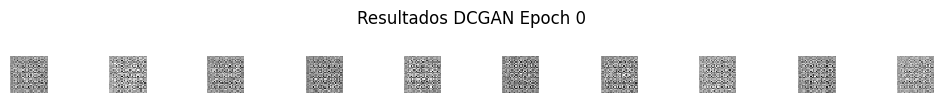

Epoch 500 [D loss: 0.8259, acc.: 4.0%] [G loss: 0.4215]


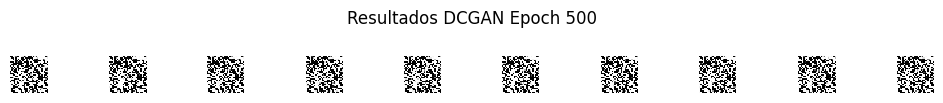

Epoch 1000 [D loss: 0.8808, acc.: 2.0%] [G loss: 0.3961]


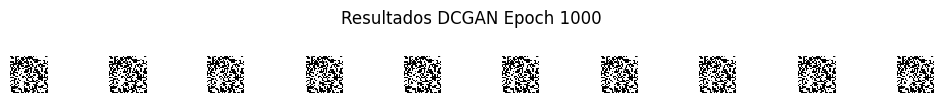

Epoch 1500 [D loss: 0.9007, acc.: 1.3%] [G loss: 0.3862]


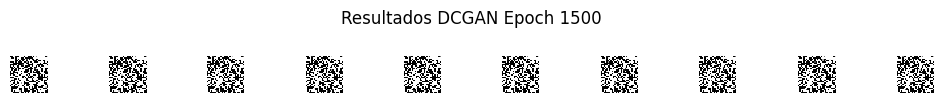

Epoch 2000 [D loss: 0.9107, acc.: 1.0%] [G loss: 0.3812]


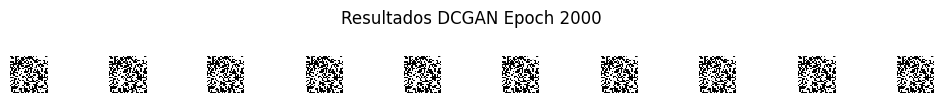

Epoch 2500 [D loss: 0.9168, acc.: 0.8%] [G loss: 0.3782]


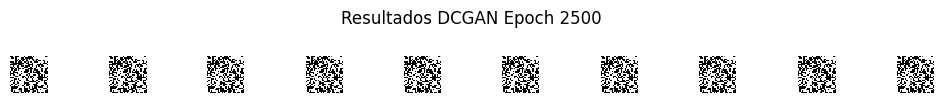

Entrenamiento DCGAN completado.


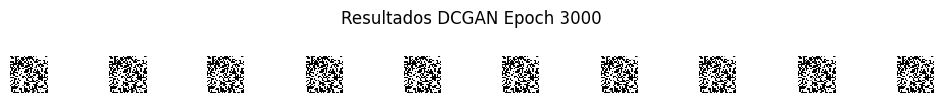

In [ ]:
# 1. Preparar datos para DCGAN (requiere dimensión de canal 28x28x1)
(X_train_dcgan, _), (_, _) = keras.datasets.mnist.load_data()
X_train_dcgan = X_train_dcgan.astype('float32') / 255.0
X_train_dcgan = X_train_dcgan.reshape(-1, 28, 28, 1) # Dimensión extra para el canal (escala de grises)

LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS = 3000

# 2. Generador DCGAN (Usa Conv2DTranspose para hacer upsampling)
def build_dcgan_generator():
    model = keras.Sequential([
        # Proyectar el mapa de ruido base a 7x7x256
        keras.layers.Dense(7 * 7 * 256, input_dim=LATENT_DIM),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Reshape((7, 7, 256)),

        # Conv2DTranspose 1: Sube de 7x7 a 14x14
        keras.layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),

        # Conv2DTranspose 2: Sube de 14x14 a 28x28
        keras.layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),

        # Conv2DTranspose final para obtener la imagen 28x28x1
        keras.layers.Conv2DTranspose(1, (5, 5), strides=(1, 1), padding='same', activation='sigmoid')
    ])
    return model

# 3. Discriminador DCGAN (Usa Conv2D tradicional para clasificación)
def build_dcgan_discriminator():
    model = keras.Sequential([
        # Conv2D 1: Recibe 28x28x1 y baja a 14x14
        keras.layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dropout(0.3),

        # Conv2D 2: Baja a 7x7
        keras.layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dropout(0.3),

        # Salida 
        keras.layers.Flatten(),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# 4. Inicialización con hiperparámetros optimizados para DCGAN
generator_dcgan = build_dcgan_generator()
discriminator_dcgan = build_dcgan_discriminator()

dcgan_opt = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

discriminator_dcgan.compile(optimizer=dcgan_opt, loss='binary_crossentropy', metrics=['accuracy'])
discriminator_dcgan.trainable = False

# Crear la red GAN combinada
z_dcgan = keras.Input(shape=(LATENT_DIM,))
img_dcgan = generator_dcgan(z_dcgan)
valid_dcgan = discriminator_dcgan(img_dcgan)
gan_dcgan = keras.Model(z_dcgan, valid_dcgan)
gan_dcgan.compile(optimizer=dcgan_opt, loss='binary_crossentropy')

# 5. Visualización para DCGAN
def plot_dcgan_images(generator, epoch, examples=10, dim=(1, 10), figsize=(10, 1)):
    noise = np.random.normal(0, 1, size=[examples, LATENT_DIM])
    generated_images = generator.predict(noise, verbose=0)
    generated_images = generated_images.reshape(examples, 28, 28) # Quitar el canal extra para plotear

    plt.figure(figsize=figsize)
    for i in range(generated_images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(generated_images[i], interpolation='nearest', cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Resultados DCGAN Epoch {epoch}')
    plt.tight_layout()
    plt.show()

# 6. Bucle de Entrenamiento
real_labels_dcgan = np.ones((BATCH_SIZE, 1)) * 0.9
fake_labels_dcgan = np.zeros((BATCH_SIZE, 1))

print("Iniciando entrenamiento DCGAN con MNIST...")

for epoch in range(EPOCHS):
    idx = np.random.randint(0, X_train_dcgan.shape[0], BATCH_SIZE)
    real_imgs = X_train_dcgan[idx]

    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    fake_imgs = generator_dcgan.predict(noise, verbose=0)

    d_loss_real = discriminator_dcgan.train_on_batch(real_imgs, real_labels_dcgan)
    d_loss_fake = discriminator_dcgan.train_on_batch(fake_imgs, fake_labels_dcgan)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    valid_labels = np.ones((BATCH_SIZE, 1))
    g_loss = gan_dcgan.train_on_batch(noise, valid_labels)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.1f}%] [G loss: {g_loss:.4f}]")
        plot_dcgan_images(generator_dcgan, epoch)

print("Entrenamiento DCGAN completado.")
plot_dcgan_images(generator_dcgan, EPOCHS)

### Conclusión Final

Tras completar los experimentos con la GAN básica y la DCGAN, podemos destacar las siguientes conclusiones clave sobre el modelado generativo de imágenes:

1.  **Ejercicio 2 (Adaptación a Fashion MNIST con Redes Densas):**
    *   **Desempeño:** La arquitectura original basada en Perceptrón Multicapa (MLP) demostró ser capaz de converger y generar siluetas reconocibles de prendas de ropa (pantalones, camisetas, zapatos).
    *   **Limitaciones Espaciales:** Sin embargo, se evidenció que las capas densas sufren de "borrosidad" (blurriness). Al "aplanar" la imagen a un vector de 784 elementos en la primera fase, la red pierde el contexto bidimensional inmediato de los píxeles (las relaciones espaciales entre bordes y gradientes), lo que hace que los detalles finos de la ropa se pierdan.

2.  **Ejercicio 3 (Implementación de DCGAN con MNIST):**
    *   **Mejora Espacial:** La transición a una arquitectura convolucional (con `Conv2D` y `Conv2DTranspose`) representó el salto cualitativo más importante. Las imágenes generadas mostraron trazos mucho más definidos y continuos que la red densa simple.
    *   **Jerarquía de Patrones:** A diferencia de la red densa, las capas convolucionales extraen características locales (bordes y esquinas) de forma progresiva, previniendo el "ruido" aislado de píxeles encendidos de forma independiente en lugar equivocado de la cuadrícula.
    *   **Estabilidad:** El uso de parámetros altamente sintonizados históricamente para las GANs (como `LeakyReLU` de `0.2`, la regularización por `BatchNormalization`, el optimizador Adam con `learning_rate=0.0002` y momentum relajado `beta_1=0.5`) permitió un ciclo adversarial más estable, controlando el riesgo de que el discriminador sobreclasifique rápidamente.

**Reflexión Final:**
Este set de ejercicios demuestra claramente la evolución del aprendizaje profundo. Mientras que las GAN tradicionales (MLP) son el laboratorio ideal para entender el concepto teórico del equilibrio *minimax* y la teoría de juegos del Generador versus el Discriminador, las arquitecturas tipo **DCGAN son el estándar indispensable cuando cruzamos la frontera hacia problemas de visión computacional**, estableciendo las bases para los modelos generativos del estado del arte en la actual era de la IA.

## 8. Referencias y Recursos

- [TensorFlow DCGAN Tutorial](https://www.tensorflow.org/tutorials/generative/dcgan)
- Goodfellow et al. (2014). *Generative Adversarial Nets.*
- [GAN Lab (Interactivo)](https://poloclub.github.io/ganlab/)
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.*

---

📎 **Notebook anterior:** [07. Transformers y Atención](./07_transformers.ipynb)  
📎 **Notebook siguiente:** [09. Autoencoders](./09_autoencoders.ipynb)